In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load datasets
sell_prices = pd.read_csv("../data/sell_prices.csv")
sales = pd.read_csv("../data/sales_train_validation.csv")
calendar = pd.read_csv("../data/calendar_clean.csv")

print("Datasets loaded successfully!")
print("Sell Prices:", sell_prices.shape)
print("Sales:", sales.shape)
print("\nFirst 5 rows:")
print(sell_prices.head())

Datasets loaded successfully!
Sell Prices: (6841121, 4)
Sales: (30490, 1919)

First 5 rows:
  store_id        item_id  wm_yr_wk  sell_price
0     CA_1  HOBBIES_1_001     11325        9.58
1     CA_1  HOBBIES_1_001     11326        9.58
2     CA_1  HOBBIES_1_001     11327        8.26
3     CA_1  HOBBIES_1_001     11328        8.26
4     CA_1  HOBBIES_1_001     11329        8.26


Price data with category:
(6841121, 6)

Price Statistics by Category:
      cat_id  avg_price  min_price  max_price  std_price
0      FOODS       3.25       0.01      19.48       2.13
1    HOBBIES       5.33       0.01      30.98       4.83
2  HOUSEHOLD       5.47       0.01     107.32       3.38


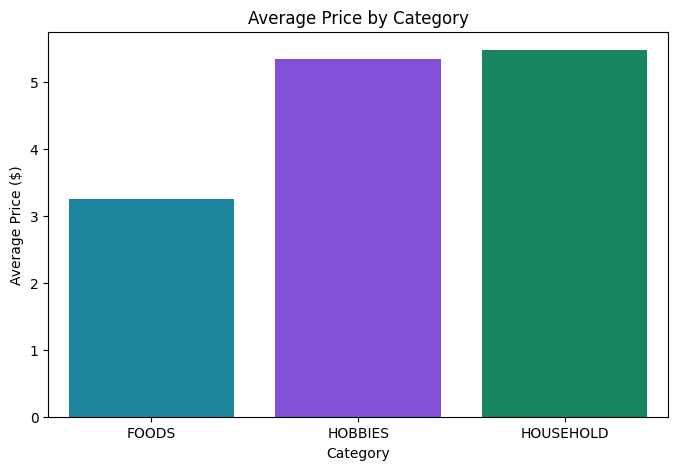

In [6]:
# Add category info to prices
sell_prices = sell_prices.merge(
    sales[['item_id', 'cat_id', 'dept_id', 'store_id']].drop_duplicates(),
    on=['item_id', 'store_id'], how='left'
)

print("Price data with category:")
print(sell_prices.shape)

# Price statistics by category
cat_price = sell_prices.groupby('cat_id')['sell_price'].agg(
    ['mean', 'min', 'max', 'std']).reset_index()
cat_price.columns = ['cat_id', 'avg_price', 'min_price', 'max_price', 'std_price']
cat_price = cat_price.round(2)

print("\nPrice Statistics by Category:")
print(cat_price)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='cat_id', y='avg_price', data=cat_price,
            palette=['#0891B2', '#7C3AED', '#059669'])
plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price ($)")
plt.show()

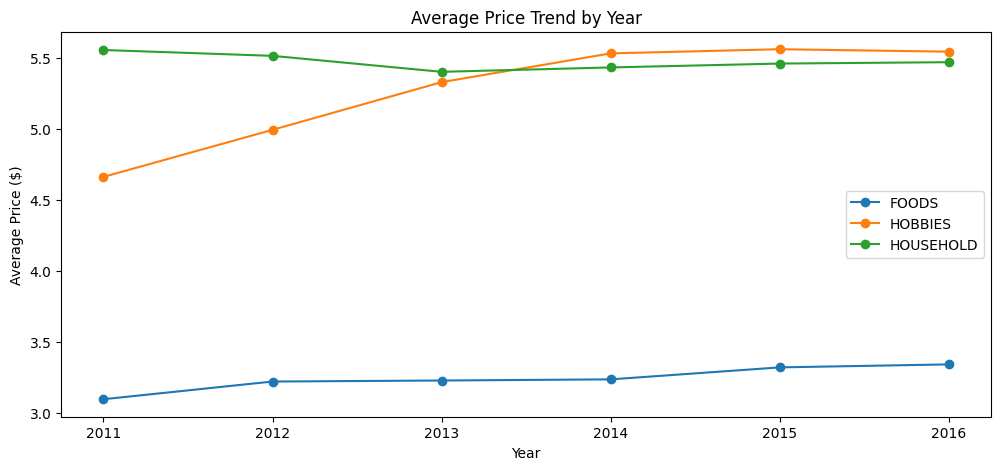

Price Trend by Year:
cat_id  FOODS  HOBBIES  HOUSEHOLD
year                             
2011     3.10     4.66       5.56
2012     3.22     5.00       5.52
2013     3.23     5.33       5.40
2014     3.24     5.53       5.44
2015     3.32     5.56       5.46
2016     3.34     5.55       5.47


In [7]:
# Price Trend Over Time
# Merge with calendar to get year
sell_prices = sell_prices.merge(
    calendar[['wm_yr_wk', 'year', 'month']].drop_duplicates(),
    on='wm_yr_wk', how='left'
)

# Average price per year by category
yearly_price = sell_prices.groupby(['year', 'cat_id'])['sell_price'].mean().reset_index()

plt.figure(figsize=(12,5))
for cat in yearly_price['cat_id'].unique():
    data = yearly_price[yearly_price['cat_id'] == cat]
    plt.plot(data['year'], data['sell_price'], marker='o', label=cat)
plt.title("Average Price Trend by Year")
plt.xlabel("Year")
plt.ylabel("Average Price ($)")
plt.legend()
plt.show()

print("Price Trend by Year:")
print(yearly_price.pivot(index='year', columns='cat_id', values='sell_price').round(2))

Correlation Matrix:
              sales  avg_price   revenue
sales      1.000000  -0.131373  0.727864
avg_price -0.131373   1.000000  0.068076
revenue    0.727864   0.068076  1.000000


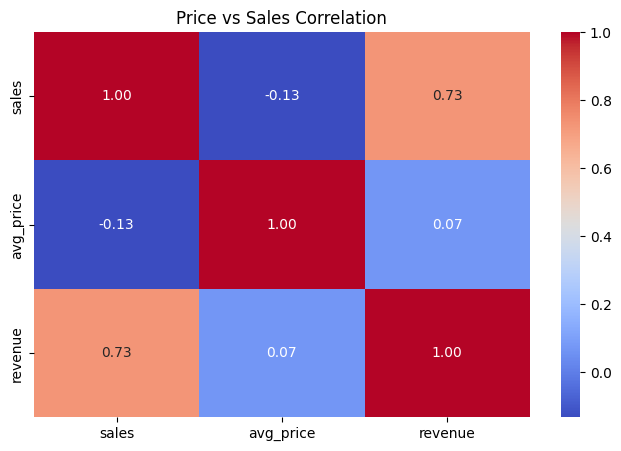


Correlation between Price and Sales: -0.131


In [8]:
# Price vs Sales Correlation
featured = pd.read_csv("../data/featured_sample.csv")

# Correlation between price and sales
correlation = featured[['sales', 'avg_price', 'revenue']].corr()

print("Correlation Matrix:")
print(correlation)

# Plot correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Price vs Sales Correlation")
plt.show()

print("\nCorrelation between Price and Sales:",
      round(featured['avg_price'].corr(featured['sales']), 3))

In [9]:
# Save price analysis
cat_price.to_csv("../data/category_price_stats.csv", index=False)
yearly_price.to_csv("../data/yearly_price_trend.csv", index=False)

print("Price analysis saved!")

print("\n" + "="*50)
print("WEEK 2 DAY 3 SUMMARY")
print("="*50)
print("Price Statistics by Category:")
print("FOODS avg price: $3.25")
print("HOBBIES avg price: $5.33")
print("HOUSEHOLD avg price: $5.47")
print("\nPrice Trend:")
print("FOODS: $3.10 to $3.34 over 6 years")
print("HOBBIES: $4.66 to $5.55 over 6 years")
print("\nPrice vs Sales Correlation: -0.131")
print("Higher price = slightly lower sales")
print("="*50)

Price analysis saved!

WEEK 2 DAY 3 SUMMARY
Price Statistics by Category:
FOODS avg price: $3.25
HOBBIES avg price: $5.33
HOUSEHOLD avg price: $5.47

Price Trend:
FOODS: $3.10 to $3.34 over 6 years
HOBBIES: $4.66 to $5.55 over 6 years

Price vs Sales Correlation: -0.131
Higher price = slightly lower sales
